In [1]:
# %matplotlib widget
import warnings
import inspect
import matplotlib.pyplot as plt
import IPython.display
import numpy as np
from cued_sf2_lab.familiarisation import load_mat_img, plot_image
from cued_sf2_lab.dct import colxfm

# 8 The Lapped Bi-orthogonal Transform (LBT)

<!-- sorry for the nasty HTML, markdown is bad for figures -->

<figure style="text-align: center">
<div class="row">
<figure class="col-md-4 col-md-offset-1">
<img src="figures/lbt.png" style="max-height: 350px" />
<figcaption>(a) Lapped Bi-orthogonal Transform</figcaption>
</figure>

<figure class="col-md-5 col-md-offset-1">
<img src="figures/pot.png" style="max-height: 350px" />
<figcaption>(b) Photo Overlap Transform and a DCT</figcaption>
</figure>
</div>
<div class="row">
<figcaption>
<br />

Figure 4: (a) An LBT transforms overlapping sections of X to create Y. (b) In some cases
this can be interpreted as pre-filtering with a POT, followed by a DCT.</figcaption></div></figure>

One of the difficulties with the DCT is that it processes each block separately and hence
does not take advantage of any correlation between blocks. A possible solution to this is
to use a _Lapped Bi-orthogonal Transform (LBT)_. These transform overlapping blocks in `X`
to generate smaller non-overlapping blocks in `Y`. In the left-hand figure above, 16 values
in `X` are used to generate each set of 8 values in `Y`.

LBTs are quite complicated to derive and analyse: however one of the most popular forms<sup>3</sup>
can also be represented as a pre-filtering operation before performing the DCT described
in the previous section.
In this case the pre-filtering (or post-filtering for the reverse
operation) is sometimes known as a _Photo Overlap Transform or POT_. A POT followed
by a DCT is then equivalent to a particular type of LBT.

The right-hand figure above demonstrates this. The POT is first performed on a section
of data `X`, shifted by `N/2`, so that it runs across the block boundaries of the subsequent
DCT. Ignoring this block shift for a moment, the forward operation for a 2D image `X` is:


$$Y = C ∗ Pf ∗ X ∗ Pf ′ ∗ C′$$

or in reverse

$$ X = Pr′ ∗ C′ ∗ Y ∗ C ∗ Pr $$

<hr />
<small><sup>3</sup>The type-II fast lapped (bi-)orthogonal transform, or LOT-II</small>

## 8.1 Applying the LBT to images

In [2]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0

The pre-filtering `Pf ∗ X ∗ Pf′` (with the correct block shift) is straightforward in Python:

```python
t = np.s_[N//2:-N//2]  # N is the DCT size, I is the image size
Xp = X.copy()  # copy the non-transformed edges directly from X
Xp[t,:] = colxfm(Xp[t,:], Pf)
Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
```

This is followed by the DCT `C` as before. In the reverse operation, the inverse DCT `C’` is
performed first, followed by Pr’:
```python
Zp = Z.copy()  #copy the non-transformed edges directly from Z
Zp[:,t] = colxfm(Zp[:,t].T, Pr.T).T
Zp[t,:] = colxfm(Zp[t,:], Pr.T)
```

We have provided a function `pot_ii(N, s)` which will generate a forward (pre-filtering,
`Pf`) and reverse (post-filtering, `Pr`) matrix of size `N` with scaling factor `s`.

In [3]:
from cued_sf2_lab.lbt import pot_ii
from cued_sf2_lab.dct import dct_ii

Edit your code
for performing DCT analysis so that it can pre-filter `X` with `Pf` before the forward DCT,
then post-filter `Z` with `Pr` after the inverse DCT. Confirm that, without quantisation, this
correctly recreates the original image, i.e. `Zp = X`. Use `Pf, Pr = pot_ii(N)` with the
default scaling value `s`.

In [4]:
Pf, Pr = pot_ii(8)
C = dct_ii(8)
t = np.s_[8//2:-8//2]
Xp = X.copy()

Xp[t,:] = colxfm(Xp[t,:], Pf)
Xp[:,t] = colxfm(Xp[:,t].T, Pf).T

Y = colxfm(Xp, C)
Z = colxfm(Y, C.T)
Zp = Z.copy()

Zp[:,t] = colxfm(Zp[:,t].T, Pr.T).T
Zp[t,:] = colxfm(Zp[t,:], Pr.T)

print(np.allclose(Zp, X))

True


## 8.2 Quantisation and coding efficiency

The scaling factor `s` determines the degree of bi-orthogonality. If `s = 1` then Pf is the same
as Pr, otherwise `1 < s < 2` weights the relative contributions of `Pf` and `Pr` un-equally.

<div class="alert alert-block alert-danger">

For an 8 × 8 DCT, try implementing an LBT with POT scaling factors varying from $1$
to $2$ ($\sqrt{2}$ is often a good choice). In each case find the quantisation step which makes
the rms error match the directly quantised image. Note the compression ratios and find
the scaling factor which maximises these. Also note the visual features in these images.</div>

Reference: direct image quantisation step = 17.000
Target RMS error = 4.8612
Direct total bits = 228119

s		best_step	RMS		bits_LBT	compression_ratio
1.0000		23.3697		4.8612		86864		2.626
1.1250		24.3812		4.8611		85191		2.678
1.2500		25.1652		4.8611		84685		2.694
1.3750		25.7717		4.8612		84735		2.692
1.4142		25.9576		4.8620		84758		2.691
1.5000		26.2263		4.8611		85265		2.675
1.6250		26.4222		4.8611		86644		2.633
1.7500		26.5332		4.8611		88633		2.574
1.8750		26.5694		4.8611		90718		2.515
2.0000		26.4441		4.8607		93437		2.441

Best scaling factor: s = 1.2500
Best matched quantisation step: 25.1652
Achieved RMS: 4.8611
LBT bits: 84685
Compression ratio direct/LBT: 2.694


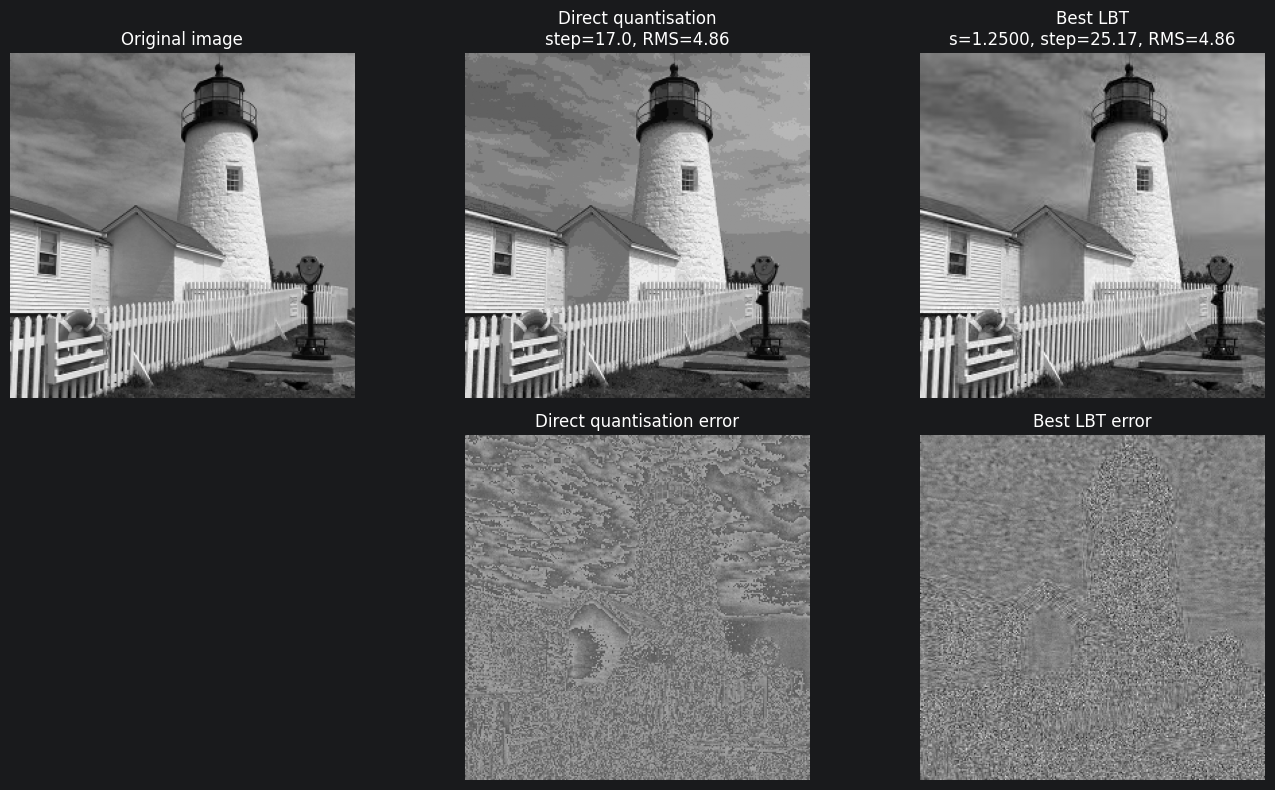

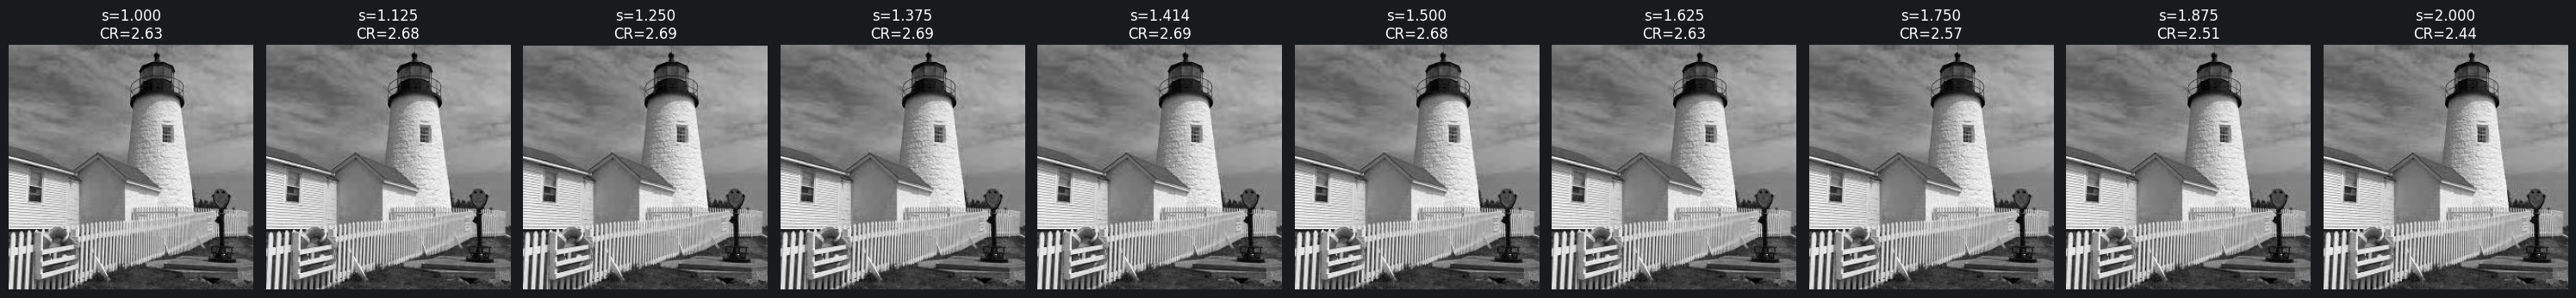

In [5]:
from cued_sf2_lab.laplacian_pyramid import bpp, quantise
from cued_sf2_lab.dct import dct_ii, colxfm, regroup
from cued_sf2_lab.lbt import pot_ii
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from numpy import sqrt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

N = 8
C = dct_ii(N)
t = np.s_[N // 2:-N // 2]

step_direct = 17.0

# Directly quantised reference image
X_q_direct = quantise(X, step_direct)
target_rms = np.std(X - X_q_direct)
total_bits_direct = bpp(X_q_direct) * X.size

print(f"Reference: direct image quantisation step = {step_direct:.3f}")
print(f"Target RMS error = {target_rms:.4f}")
print(f"Direct total bits = {total_bits_direct:.0f}")
print()

# Scaling factors to test
s_values = np.linspace(1.0, 2.0, 9).tolist()
s_values.append(np.sqrt(2))
s_values = sorted(set(np.round(s_values, 10)))

results = []


# ------------------------------------------------------------
# Helper: estimate total bits
# ------------------------------------------------------------

def estimate_bits(Yq):
    """
    Estimate bits for quantised transform coefficients.
    Uses dctbpp if you already defined it in Part 7.
    Otherwise falls back to entropy estimate bpp(Yq) * number of samples.
    """
    try:
        Yr = regroup(Yq, N)
        return dctbpp(Yr, N)
    except NameError:
        return bpp(Yq) * Yq.size


# ------------------------------------------------------------
# Helper: LBT encode/decode for a given s and quantisation step
# ------------------------------------------------------------

def lbt_reconstruct(X, s, step_q):
    Pf, Pr = pot_ii(N, s)

    # Forward POT pre-filter
    Xp = X.copy()
    Xp[t, :] = colxfm(Xp[t, :], Pf)
    Xp[:, t] = colxfm(Xp[:, t].T, Pf).T

    # Forward 2D DCT
    Y = colxfm(colxfm(Xp, C).T, C).T

    # Quantise transform coefficients
    Yq = quantise(Y, step_q)

    # Inverse 2D DCT
    Z = colxfm(colxfm(Yq.T, C.T).T, C.T)

    # Inverse POT post-filter
    Zp = Z.copy()
    Zp[:, t] = colxfm(Zp[:, t].T, Pr.T).T
    Zp[t, :] = colxfm(Zp[t, :], Pr.T)

    Xrec = Zp

    rms = np.std(X - Xrec)
    bits = estimate_bits(Yq)

    return rms, bits, Xrec, Yq


# ------------------------------------------------------------
# For each s, find quantisation step matching direct RMS
# ------------------------------------------------------------

for s in s_values:
    def objective(step_q):
        rms, _, _, _ = lbt_reconstruct(X, s, step_q)
        return abs(rms - target_rms)


    res = scipy.optimize.minimize_scalar(
        objective,
        bounds=(0.01, 200.0),
        method='bounded',
        options={'xatol': 1e-3}
    )

    best_step = float(res.x)
    achieved_rms, bits_lbt, Xrec_best, Yq_best = lbt_reconstruct(X, s, best_step)

    compression_ratio = total_bits_direct / bits_lbt

    results.append({
        "s": s,
        "best_step": best_step,
        "achieved_rms": achieved_rms,
        "bits_lbt": bits_lbt,
        "compression_ratio": compression_ratio,
        "Xrec": Xrec_best,
        "Yq": Yq_best
    })

# ------------------------------------------------------------
# Print table
# ------------------------------------------------------------

print("s\t\tbest_step\tRMS\t\tbits_LBT\tcompression_ratio")
for r in results:
    print(
        f"{r['s']:.4f}\t\t"
        f"{r['best_step']:.4f}\t\t"
        f"{r['achieved_rms']:.4f}\t\t"
        f"{r['bits_lbt']:.0f}\t\t"
        f"{r['compression_ratio']:.3f}"
    )

best = max(results, key=lambda r: r["compression_ratio"])

print()
print(f"Best scaling factor: s = {best['s']:.4f}")
print(f"Best matched quantisation step: {best['best_step']:.4f}")
print(f"Achieved RMS: {best['achieved_rms']:.4f}")
print(f"LBT bits: {best['bits_lbt']:.0f}")
print(f"Compression ratio direct/LBT: {best['compression_ratio']:.3f}")

# ------------------------------------------------------------
# Image comparison: direct quantisation vs best LBT
# ------------------------------------------------------------

X_lbt_best = best["Xrec"]

err_direct = X - X_q_direct
err_lbt = X - X_lbt_best

vmin = np.min(X)
vmax = np.max(X)

err_lim = max(np.max(np.abs(err_direct)), np.max(np.abs(err_lbt)))

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(X, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Original image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(X_q_direct, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f"Direct quantisation\nstep={step_direct}, RMS={target_rms:.2f}")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(X_lbt_best, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(
    f"Best LBT\n"
    f"s={best['s']:.4f}, step={best['best_step']:.2f}, RMS={best['achieved_rms']:.2f}"
)
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(err_direct, cmap='gray', vmin=-err_lim, vmax=err_lim)
plt.title("Direct quantisation error")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(err_lbt, cmap='gray', vmin=-err_lim, vmax=err_lim)
plt.title("Best LBT error")
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: compare all scaling factors visually
# ------------------------------------------------------------

cols = len(results)
plt.figure(figsize=(3 * cols, 4))

for i, r in enumerate(results):
    plt.subplot(1, cols, i + 1)
    plt.imshow(r["Xrec"], cmap='gray', vmin=vmin, vmax=vmax)
    plt.title(
        f"s={r['s']:.3f}\n"
        f"CR={r['compression_ratio']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

The POT can often improve both compression and block smoothing, since the pre-filter
acts to reduce correlations between each DCT sub-block, whilst the inverse post-filter
acts to remove the discontinuities between sub-blocks. This is rather different from the
operation of the DCT. Investigate this by looking at the basis functions, as you did with
the DCT:

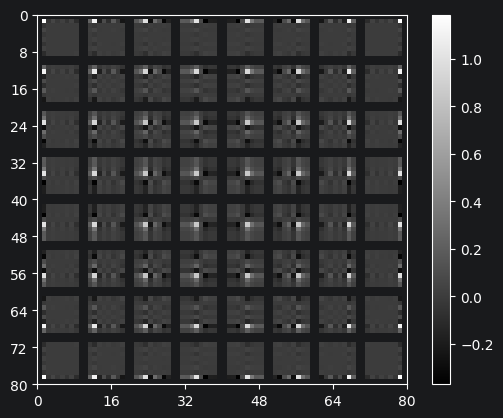

In [6]:
Pf, Pr = pot_ii(8)
bases = np.concatenate([np.full((8,1), np.nan), Pf, np.full((8,1), np.nan)], axis=1)
bases = bases.reshape(-1, 1)
fig, ax = plt.subplots()
im_obj = plot_image(bases @ bases.T, ax=ax)
fig.colorbar(im_obj, ax=ax);

<div class="alert alert-block alert-danger">

Look at both these bases and the pre-filtered image `Xp`, using different scaling factors
`s`, and comment on the visual effect of varying these scaling factors. You may need to
multiply `Xp` by up to 0.5 to display it better.</div>

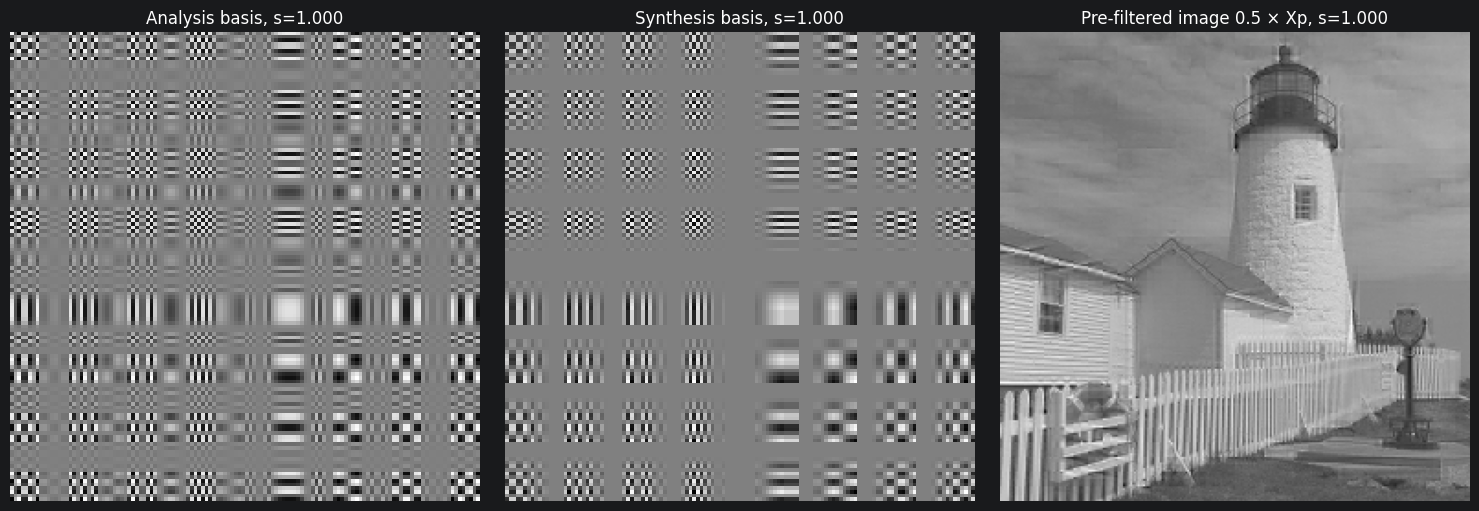

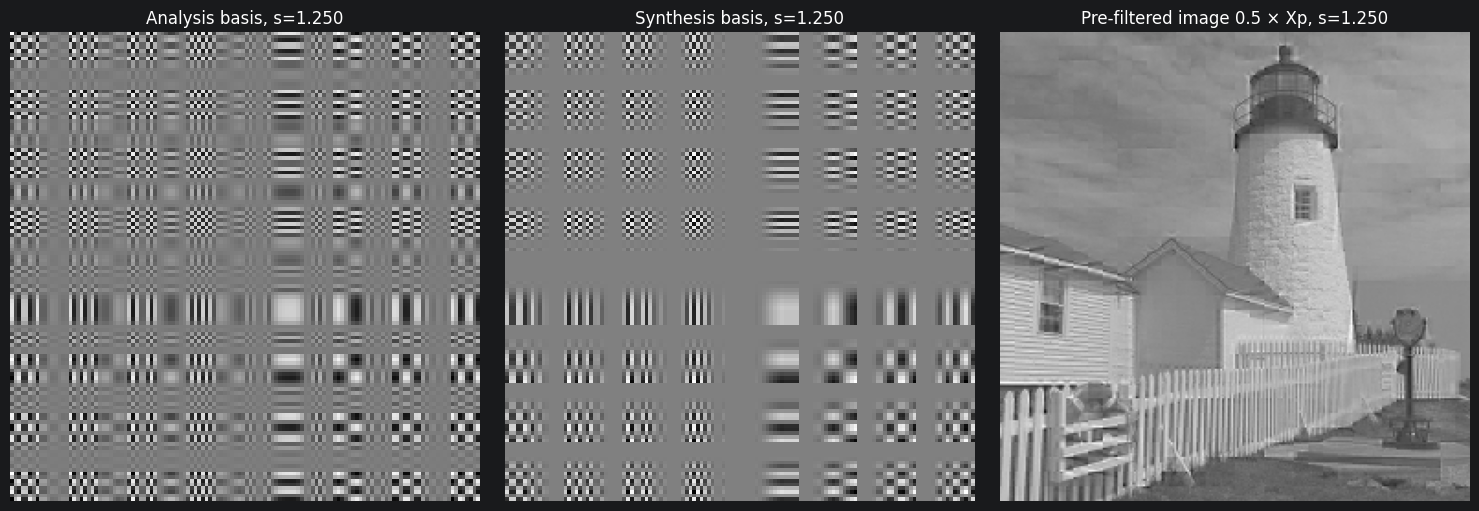

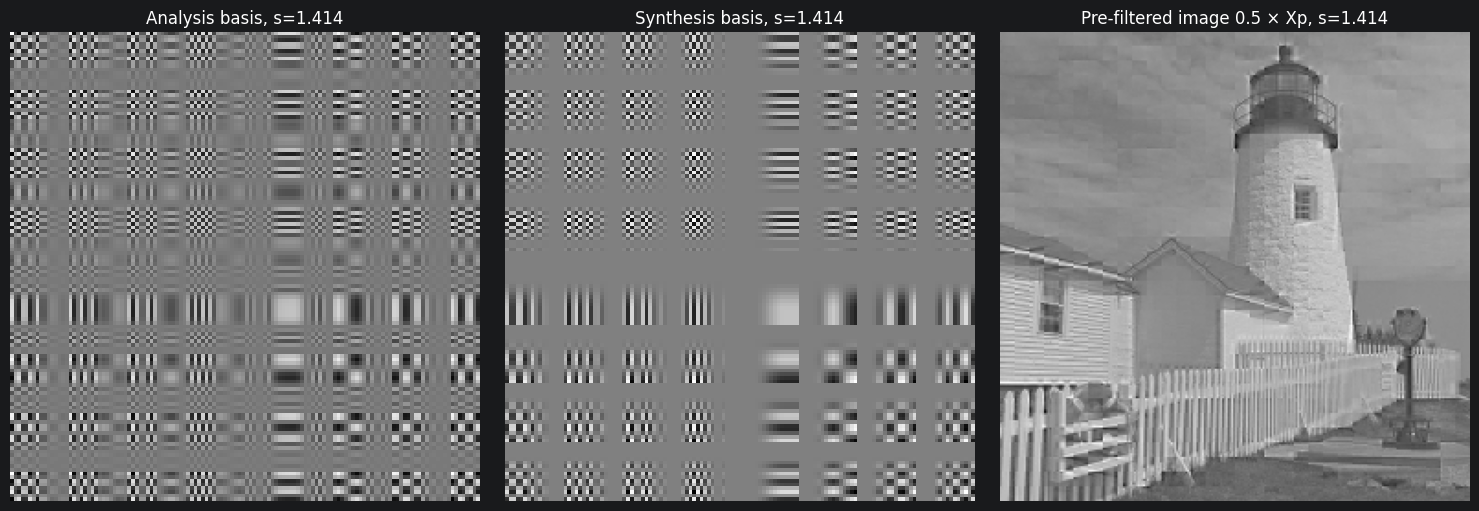

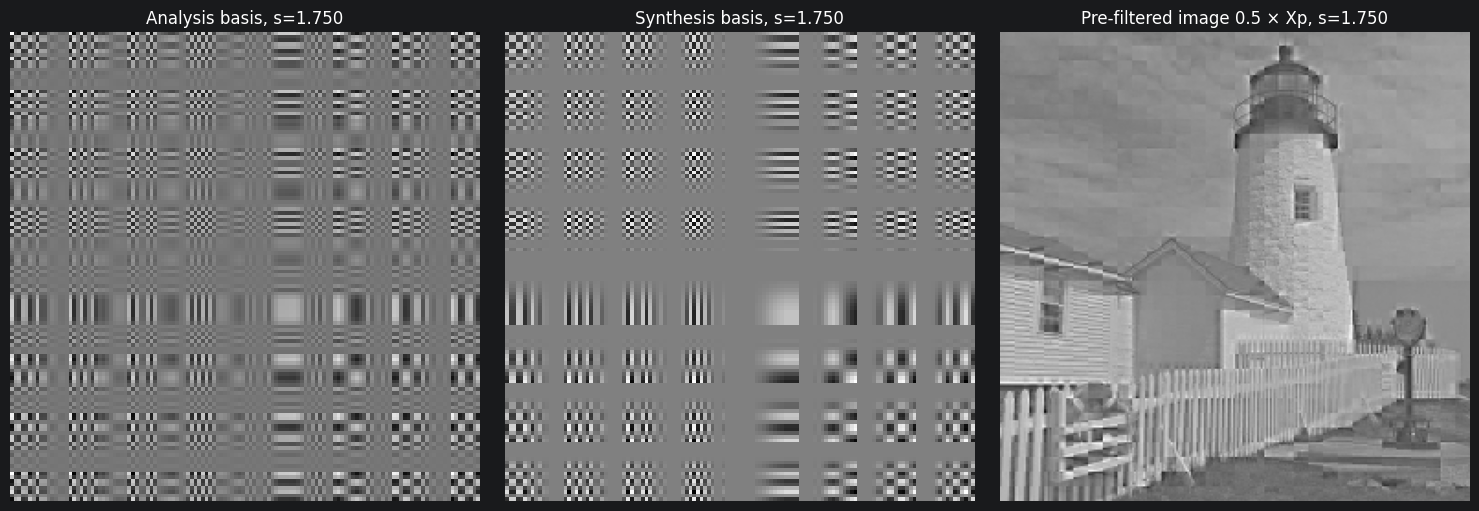

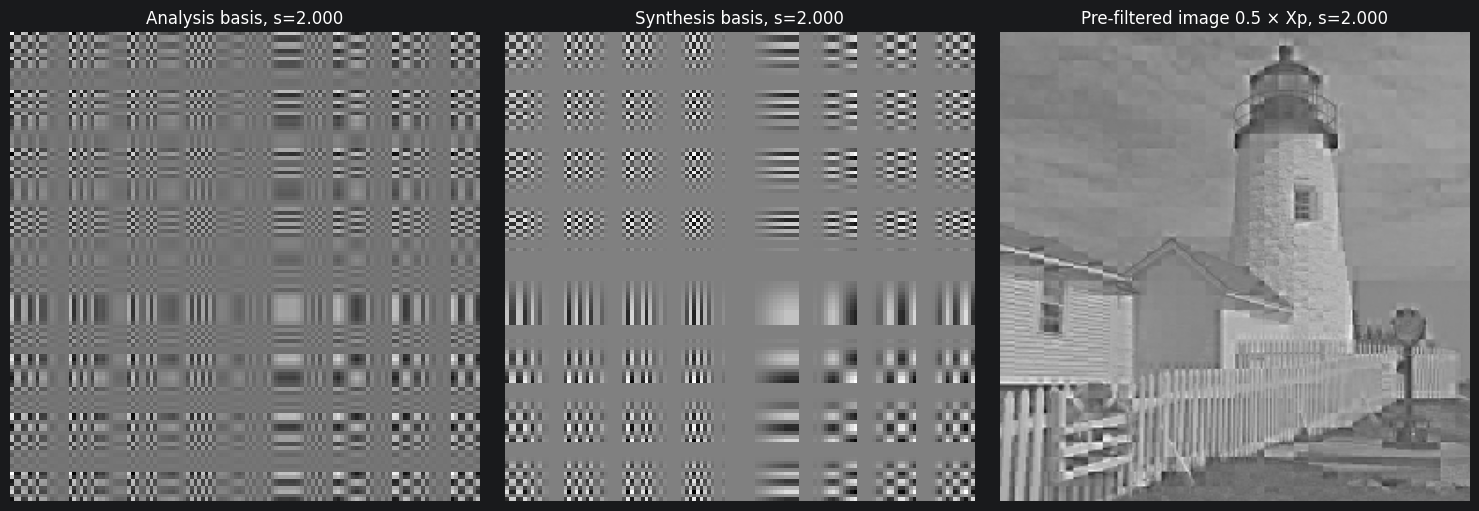

In [7]:
from cued_sf2_lab.dct import dct_ii, colxfm
from cued_sf2_lab.lbt import pot_ii
import numpy as np
import matplotlib.pyplot as plt

N = 8
C = dct_ii(N)
t = np.s_[N // 2:-N // 2]

# Try a few POT scaling factors
s_values = [1.0, 1.25, np.sqrt(2), 1.75, 2.0]


def make_lbt_basis(Pf, Pr, C, N):
    """
    Create approximate LBT analysis and synthesis basis images.

    Analysis basis: shows effect of pre-filter + DCT.
    Synthesis basis: shows inverse DCT + post-filter.
    """
    size = 2 * N
    centre_block = np.s_[N // 2:N // 2 + N, N // 2:N // 2 + N]
    t_big = np.s_[N // 2:-N // 2]

    analysis_basis = np.zeros((size * N, size * N))
    synthesis_basis = np.zeros((size * N, size * N))

    for u in range(N):
        for v in range(N):
            impulse = np.zeros((size, size))
            impulse[centre_block][u, v] = 1

            # -----------------------------
            # Analysis basis
            # -----------------------------
            A = impulse.copy()

            # POT pre-filter
            A[t_big, :] = colxfm(A[t_big, :], Pf)
            A[:, t_big] = colxfm(A[:, t_big].T, Pf).T

            # 2D DCT
            A = colxfm(colxfm(A, C).T, C).T

            analysis_basis[
                u * size:(u + 1) * size,
                v * size:(v + 1) * size
            ] = A

            # -----------------------------
            # Synthesis basis
            # -----------------------------
            S = np.zeros((size, size))
            S[centre_block][u, v] = 1

            # inverse 2D DCT
            S = colxfm(colxfm(S.T, C.T).T, C.T)

            # POT post-filter
            S[:, t_big] = colxfm(S[:, t_big].T, Pr.T).T
            S[t_big, :] = colxfm(S[t_big, :], Pr.T)

            synthesis_basis[
                u * size:(u + 1) * size,
                v * size:(v + 1) * size
            ] = S

    return analysis_basis, synthesis_basis


def prefilter_image(X, s):
    """
    Apply only the LBT pre-filter to image X.
    """
    Pf, Pr = pot_ii(N, s)

    Xp = X.copy()
    Xp[t, :] = colxfm(Xp[t, :], Pf)
    Xp[:, t] = colxfm(Xp[:, t].T, Pf).T

    return Xp


# ------------------------------------------------------------
# Display analysis basis, synthesis basis, and pre-filtered Xp
# ------------------------------------------------------------

for s in s_values:
    Pf, Pr = pot_ii(N, s)

    analysis_basis, synthesis_basis = make_lbt_basis(Pf, Pr, C, N)
    Xp = prefilter_image(X, s)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(analysis_basis, cmap='gray')
    plt.title(f"Analysis basis, s={s:.3f}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(synthesis_basis, cmap='gray')
    plt.title(f"Synthesis basis, s={s:.3f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(0.5 * Xp, cmap='gray')
    plt.title(f"Pre-filtered image 0.5 × Xp, s={s:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

With this type of POT / DCT combination it is common to use smaller DCT block sizes
but to code several blocks together. Hence a more accurate estimate of the number of bits
is found by always using 16 × 16 blocks, i.e. regroup `Yq` with the correct size `N` to give
`Yr`, but then always use `dctbpp(Yr, 16)`.

<div class="alert alert-block alert-danger">

Investigate the relative visual and compression performance of LBTs with 4 × 4, 8 × 8
and 16 × 16 blocks, using the scaling factor you have previously selected. As before, be
careful to match the rms error with a directly quantised image.</div>

Direct quantisation step = 17.000
Target RMS error = 4.8612
Direct total bits = 228119

Using selected scaling factor s = 1.2500

N	step		RMS		bits_LBT	compression_ratio
4	27.1671		4.8611		64724		3.524
8	25.1652		4.8611		66842		3.413
16	22.6424		4.8607		77373		2.948

Best block size: N = 4
Best matched quantisation step: 27.1671
Achieved RMS: 4.8611
LBT bits: 64724
Compression ratio direct/LBT: 3.524


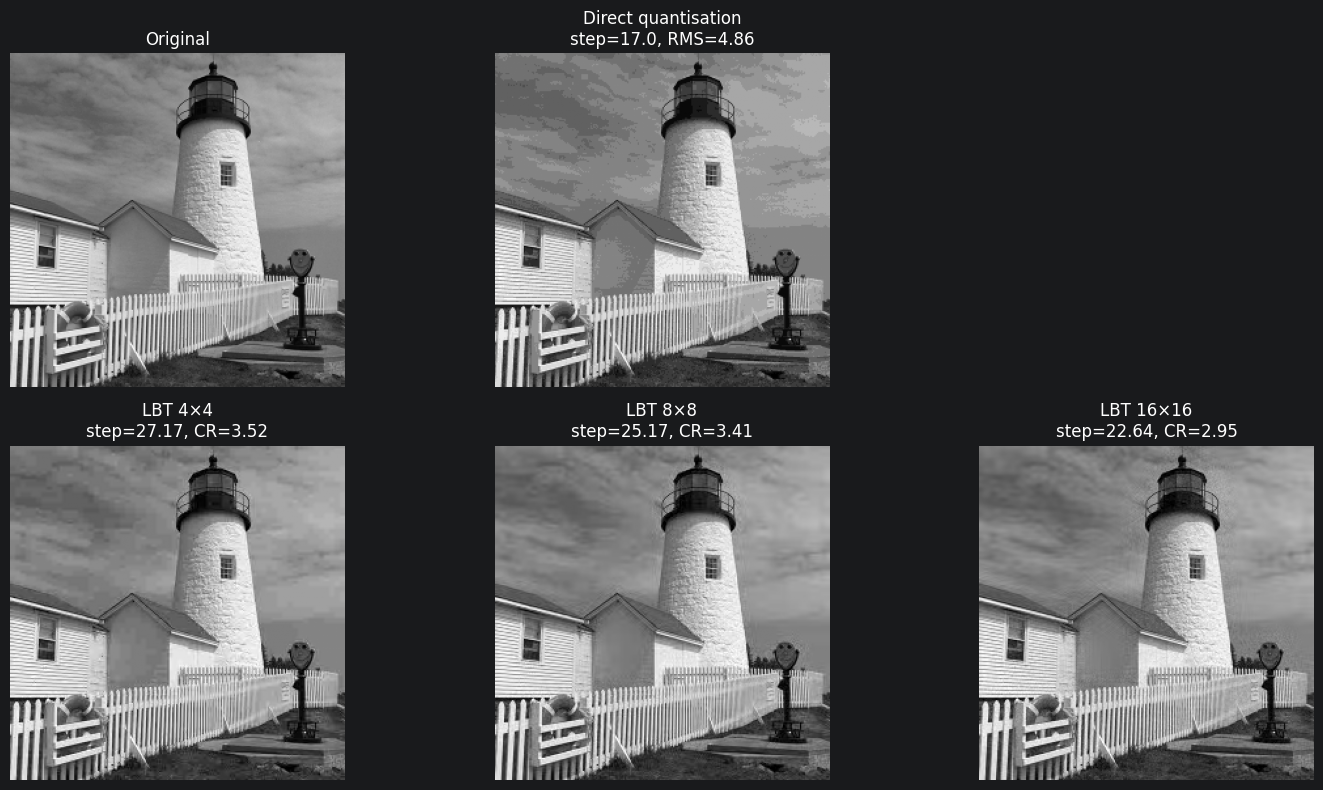

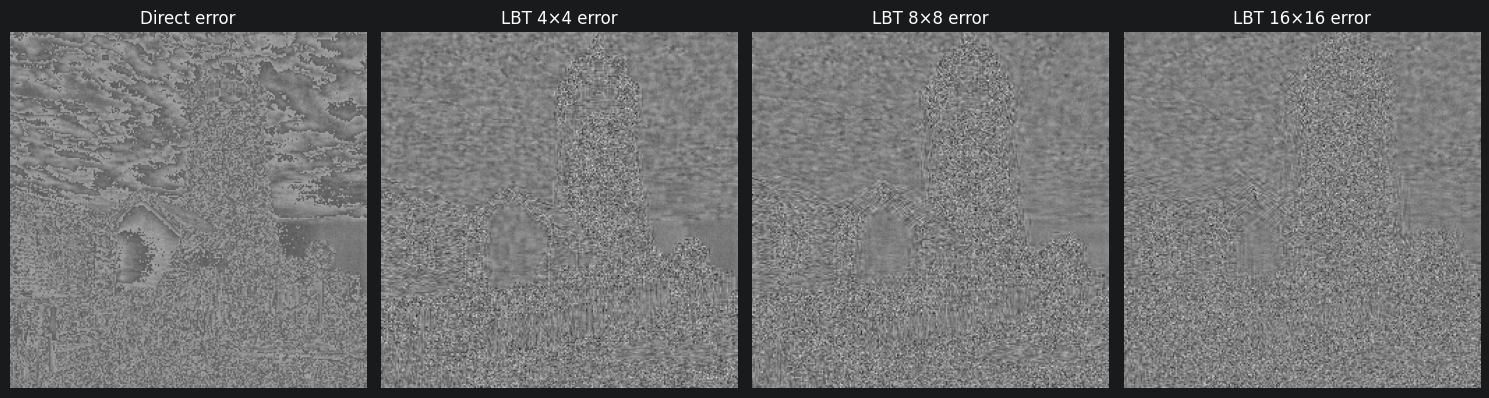

In [8]:
from cued_sf2_lab.laplacian_pyramid import bpp, quantise
from cued_sf2_lab.dct import dct_ii, colxfm, regroup
from cued_sf2_lab.lbt import pot_ii
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Direct quantisation reference
# ------------------------------------------------------------

step_direct = 17.0

X_q_direct = quantise(X, step_direct)
target_rms = np.std(X - X_q_direct)
total_bits_direct = bpp(X_q_direct) * X.size

print(f"Direct quantisation step = {step_direct:.3f}")
print(f"Target RMS error = {target_rms:.4f}")
print(f"Direct total bits = {total_bits_direct:.0f}")
print()

def dctbpp(Yr, N=16):
    """
    Estimate total bits for regrouped DCT/LBT coefficients.

    Yr should already be regrouped using the actual transform block size.
    N is the coding block size. For this lab section, use N=16.
    """
    total_bits = 0

    for i in range(0, Yr.shape[0], N):
        for j in range(0, Yr.shape[1], N):
            block = Yr[i:i+N, j:j+N]
            total_bits += bpp(block) * block.size

    return total_bits

# ------------------------------------------------------------
# Use your previously selected best scaling factor
# ------------------------------------------------------------

# If you already have a variable called best from the previous section,
# this will use it automatically. Otherwise it uses sqrt(2).
try:
    s_selected = best["s"]
except NameError:
    s_selected = np.sqrt(2)

print(f"Using selected scaling factor s = {s_selected:.4f}")
print()


# ------------------------------------------------------------
# Helper: LBT reconstruction for variable block size N
# ------------------------------------------------------------

def lbt_reconstruct_N(X, N, s, step_q):
    C = dct_ii(N)
    Pf, Pr = pot_ii(N, s)
    t = np.s_[N // 2:-N // 2]

    # Forward POT pre-filter
    Xp = X.copy()
    Xp[t, :] = colxfm(Xp[t, :], Pf)
    Xp[:, t] = colxfm(Xp[:, t].T, Pf).T

    # Forward 2D DCT
    Y = colxfm(colxfm(Xp, C).T, C).T

    # Quantise LBT/DCT coefficients
    Yq = quantise(Y, step_q)

    # Inverse 2D DCT
    Z = colxfm(colxfm(Yq.T, C.T).T, C.T)

    # Inverse POT post-filter
    Zp = Z.copy()
    Zp[:, t] = colxfm(Zp[:, t].T, Pr.T).T
    Zp[t, :] = colxfm(Zp[t, :], Pr.T)

    Xrec = Zp
    rms = np.std(X - Xrec)

    # Important instruction from lab:
    # regroup using the actual block size N,
    # but always estimate bits with 16 x 16 blocks.
    Yr = regroup(Yq, N)
    bits = dctbpp(Yr, 16)

    return rms, bits, Xrec, Yq, Yr


# ------------------------------------------------------------
# Match RMS error for N = 4, 8, 16
# ------------------------------------------------------------

block_sizes = [4, 8, 16]
results_N = []

for N in block_sizes:
    def objective(step_q):
        rms, _, _, _, _ = lbt_reconstruct_N(X, N, s_selected, step_q)
        return abs(rms - target_rms)


    res = scipy.optimize.minimize_scalar(
        objective,
        bounds=(0.01, 200.0),
        method="bounded",
        options={"xatol": 1e-3}
    )

    best_step = float(res.x)
    achieved_rms, bits_lbt, Xrec, Yq, Yr = lbt_reconstruct_N(
        X, N, s_selected, best_step
    )

    compression_ratio = total_bits_direct / bits_lbt

    results_N.append({
        "N": N,
        "step": best_step,
        "rms": achieved_rms,
        "bits": bits_lbt,
        "compression_ratio": compression_ratio,
        "Xrec": Xrec,
        "Yq": Yq,
        "Yr": Yr
    })

# ------------------------------------------------------------
# Print summary table
# ------------------------------------------------------------

print("N\tstep\t\tRMS\t\tbits_LBT\tcompression_ratio")
for r in results_N:
    print(
        f"{r['N']}\t"
        f"{r['step']:.4f}\t\t"
        f"{r['rms']:.4f}\t\t"
        f"{r['bits']:.0f}\t\t"
        f"{r['compression_ratio']:.3f}"
    )

best_N = max(results_N, key=lambda r: r["compression_ratio"])

print()
print(f"Best block size: N = {best_N['N']}")
print(f"Best matched quantisation step: {best_N['step']:.4f}")
print(f"Achieved RMS: {best_N['rms']:.4f}")
print(f"LBT bits: {best_N['bits']:.0f}")
print(f"Compression ratio direct/LBT: {best_N['compression_ratio']:.3f}")

# ------------------------------------------------------------
# Visual comparison: original, direct quantisation, LBTs
# ------------------------------------------------------------

vmin = np.min(X)
vmax = np.max(X)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(X, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(X_q_direct, cmap="gray", vmin=vmin, vmax=vmax)
plt.title(f"Direct quantisation\nstep={step_direct}, RMS={target_rms:.2f}")
plt.axis("off")

for i, r in enumerate(results_N):
    plt.subplot(2, 3, i + 4)
    plt.imshow(r["Xrec"], cmap="gray", vmin=vmin, vmax=vmax)
    plt.title(
        f"LBT {r['N']}×{r['N']}\n"
        f"step={r['step']:.2f}, CR={r['compression_ratio']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Error image comparison
# ------------------------------------------------------------

errors = [X - X_q_direct] + [X - r["Xrec"] for r in results_N]
err_lim = max(np.max(np.abs(e)) for e in errors)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(errors[0], cmap="gray", vmin=-err_lim, vmax=err_lim)
plt.title("Direct error")
plt.axis("off")

for i, r in enumerate(results_N):
    plt.subplot(1, 4, i + 2)
    plt.imshow(errors[i + 1], cmap="gray", vmin=-err_lim, vmax=err_lim)
    plt.title(f"LBT {r['N']}×{r['N']} error")
    plt.axis("off")

plt.tight_layout()
plt.show()